## 1 Data preparation

In [ ]:
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

ENGINEERED_DIR = r"D:/uni/Intern-1-Project/ksl/landmarks_30frames_engineered"
SEQUENCE_LENGTH = 30
FEATURES_PER_FRAME = 686  

# ============================================================
# LOAD AND PREPARE DATA
# ============================================================

def load_data(base_dir):
    """
    Load all .npy files and create X (features) and y (labels)
    """
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f" Directory not found: {base_path}")
        return None, None
    
    X = []  # Features
    y = []  # Labels
    
    # Get all class folders
    class_folders = sorted([d for d in base_path.iterdir() if d.is_dir()])
    
    print(f"Found {len(class_folders)} classes")
    print("-" * 60)
    
    for class_idx, class_path in enumerate(class_folders):
        class_name = class_path.name
        npy_files = sorted(class_path.glob("*.npy"))
        
        print(f"  {class_idx}: {class_name} - {len(npy_files)} samples")
        
        for file_path in npy_files:
            try:
                data = np.load(file_path)
                
                # Ensure correct shape
                if data.shape != (SEQUENCE_LENGTH, FEATURES_PER_FRAME):
                    print(f"     Skipping {file_path.name}: shape {data.shape}")
                    continue
                
                X.append(data)
                y.append(class_idx)
                
            except Exception as e:
                print(f"     Error loading {file_path.name}: {e}")
    
    X = np.array(X)
    y = np.array(y)
    
    print("-" * 60)
    print(f" Total samples loaded: {len(X)}")
    print(f"   Shape: {X.shape}")
    print(f"   Classes: {len(np.unique(y))}")
    
    return X, y, [d.name for d in class_folders]

# Load data
X, y, class_names = load_data(ENGINEERED_DIR)

if X is None:
    print(" No data loaded!")
    exit()

 Directory not found: D:\uni\Intern-1-Project\ksl\landmarks_30frames_engineered


ValueError: not enough values to unpack (expected 3, got 2)

## 2 Train test spilt

In [2]:
# ============================================================
# SPLIT DATA - 80% TRAINING, 20% FOR VAL + TEST
# ============================================================

def split_data(X, y, train_size=0.8, val_ratio=0.5):
    """
    Split data into train, validation, and test sets
    - 80% for training
    - Remaining 20% split equally between val and test (10% each)
    
    Args:
        train_size: Proportion for training (default: 0.8)
        val_ratio: Proportion of remaining data for validation (default: 0.5)
                   If 0.5, val and test are equal (10% each)
                   If 0.7, val=14%, test=6%
                   If 0.3, val=6%, test=14%
    """
    # First split: train and temp (val + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, 
        train_size=train_size, 
        random_state=42, 
        stratify=y
    )
    
    # Second split: val and test from temp
    val_size = val_ratio  # Proportion of temp for validation
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1 - val_ratio),
        random_state=42,
        stratify=y_temp
    )
    
    print("\n" + "=" * 70)
    print("DATA SPLIT SUMMARY")
    print("=" * 70)
    print(f"Total samples:  {len(X)}")
    print(f"Training:       {len(X_train):5d} ({len(X_train)/len(X)*100:5.1f}%)")
    print(f"Validation:     {len(X_val):5d} ({len(X_val)/len(X)*100:5.1f}%)")
    print(f"Test:           {len(X_test):5d} ({len(X_test)/len(X)*100:5.1f}%)")
    print("-" * 70)
    print(f"Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Use 80% training, 10% validation, 10% test
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X, y, 
    train_size=0.8,  # 80% training
    val_ratio=0.5    # 50% of remaining for val (10% of total)
)

# One-hot encode labels
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"\nClasses: {num_classes}")
print(f"Class names: {class_names}")

# Show per-class distribution in each split
print("\n" + "=" * 70)
print("PER-CLASS DISTRIBUTION IN SPLITS")
print("=" * 70)
print(f"{'Class':<20} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
print("-" * 70)

for i, class_name in enumerate(class_names):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)
    total_count = train_count + val_count + test_count
    print(f"{class_name:<20} {train_count:<8} {val_count:<8} {test_count:<8} {total_count:<8}")



DATA SPLIT SUMMARY
Total samples:  11643
Training:        9314 ( 80.0%)
Validation:      1164 ( 10.0%)
Test:            1165 ( 10.0%)
----------------------------------------------------------------------
Train/Val/Test: 9314/1164/1165

Classes: 20
Class names: ['កាតាប', 'កាតាបស្ពាយក្រោយ', 'កុំព្យូទ័រ', 'កៅអី', 'ក្ដារខៀន', 'ខ្មៅដៃ', 'ជ័រលុប', 'ដីស', 'តុ', 'ទឹកលុប', 'នាយករង', 'នាយិកា', 'បន្ទាត់', 'ប៊ិក', 'ប៊ិកក្រហម', 'ប៊ិកខៀវ', 'សៀវភៅ', 'ហ្វឺតក្រហម', 'ហ្វឺតខៀវ', 'ហ្វឺតខ្មៅ']

PER-CLASS DISTRIBUTION IN SPLITS
Class                Train    Val      Test     Total   
----------------------------------------------------------------------
កាតាប                449      56       56       561     
កាតាបស្ពាយក្រោយ      386      48       48       482     
កុំព្យូទ័រ           534      67       67       668     
កៅអី                 276      35       34       345     
ក្ដារខៀន             287      36       36       359     
ខ្មៅដៃ               457      57       57       571     
ជ័រលុប          

## 3 Build model

In [5]:
import tensorflow as tf
from tensorflow.keras import layers
def build_bgru_with_attention(input_shape, num_classes):
    """
    Bidirectional GRU with attention — efficient and effective
    """
    inputs = tf.keras.Input(shape=input_shape)

    # Input normalization
    x = layers.BatchNormalization()(inputs)

    # 1D Conv to extract local patterns first
    x = layers.Conv1D(filters=64, kernel_size=3,
                      padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # BiGRU layer 1 — reads both directions
    x = layers.Bidirectional(
        layers.GRU(
            128,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2,
            activation='tanh',
            recurrent_activation='sigmoid'
        )
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # BiGRU layer 2 — deeper context
    x = layers.Bidirectional(
        layers.GRU(
            64,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2,
            activation='tanh',
            recurrent_activation='sigmoid'
        )
    )(x)
    x = layers.Dropout(0.3)(x)

    # Attention — focus on important frames (especially end of sign)
    # BiGRU output is 128 (64×2 from bidirectional)
    attention = layers.Dense(1, activation='tanh')(x)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(128)(attention)  # 64×2 = 128
    attention = layers.Permute([2, 1])(attention)

    # Apply attention weights
    x = layers.Multiply()([x, attention])
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs,
                          name='BiGRU_Attention')



# ── Build ─────────────────────────────────────────────────────
input_shape = (SEQUENCE_LENGTH, FEATURES_PER_FRAME)
model       = build_bgru_with_attention(input_shape, num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "BiGRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 686)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 686)   │      2,744 │ input_layer_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │    131,776 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 256)   │    148,992 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 30, 128)   │    123,648 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 30)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 30)   │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 30, 128)   │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 30, 128)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 419,821 (1.60 MB)

 Trainable params: 417,681 (1.59 MB)

 Non-trainable params: 2,140 (8.36 KB)

## Model config

In [6]:
# ============================================================
# TRAIN WITH CALLBACKS & CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

def get_callbacks(model_save_path):
    """
    Create callbacks for training
    """
    callbacks = [
        # Early stopping - stop if no improvement
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate on plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
        
        # Save best model
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    return callbacks

# ============================================================
# COMPUTE CLASS WEIGHTS (FOR IMBALANCED DATA)
# ============================================================

print("=" * 60)
print("COMPUTING CLASS WEIGHTS")
print("=" * 60)

# Calculate class weights from training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format for Keras
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Display class weights
print(f"\n{'Class':<25} {'Samples':<10} {'Weight':<10}")
print("-" * 60)
for i, class_name in enumerate(class_names):
    samples = np.sum(y_train == i)
    weight = class_weights[i]
    print(f"{class_name:<25} {samples:<10} {weight:<10.3f}")

print("\n" + "=" * 60)
print("CLASS WEIGHT SUMMARY")
print("=" * 60)
print(f"Min weight: {min(class_weights):.3f} (majority class)")
print(f"Max weight: {max(class_weights):.3f} (minority class)")
print(f"Weight ratio: {max(class_weights)/min(class_weights):.2f}x")

# ============================================================
# TRAIN THE MODEL WITH CLASS WEIGHTS
# ============================================================

# Model save path
MODEL_SAVE_PATH = r"D:/uni/Intern-1-Project/ksl/models/bgru_best_model_v1.h5"

# Get callbacks
callbacks = get_callbacks(MODEL_SAVE_PATH)

# Train the model
print("\n" + "=" * 60)
print("STARTING TRAINING WITH CLASS WEIGHTS")
print("=" * 60)
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Classes:            {len(class_names)}")
print(f"Class weights:      Applied ✓")
print("-" * 60)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,  # ← This handles class imbalance!
    callbacks=callbacks,
    verbose=1
)


COMPUTING CLASS WEIGHTS

Class                     Samples    Weight    
------------------------------------------------------------
កាតាប                     449        1.037     
កាតាបស្ពាយក្រោយ           386        1.206     
កុំព្យូទ័រ                534        0.872     
កៅអី                      276        1.687     
ក្ដារខៀន                  287        1.623     
ខ្មៅដៃ                    457        1.019     
ជ័រលុប                    320        1.455     
ដីស                       346        1.346     
តុ                        325        1.433     
ទឹកលុប                    638        0.730     
នាយករង                    344        1.354     
នាយិកា                    502        0.928     
បន្ទាត់                   213        2.186     
ប៊ិក                      466        0.999     
ប៊ិកក្រហម                 705        0.661     
ប៊ិកខៀវ                   769        0.606     
សៀវភៅ                     370        1.259     
ហ្វឺតក្រហម                716        0.650     
ហ្

292/292 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.2962 - loss: 2.2063 - val_accuracy: 0.5610 - val_loss: 2.0089 - learning_rate: 0.0010
Epoch 2/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6253 - loss: 0.8820
Epoch 2: val_accuracy improved from 0.56100 to 0.70962, saving model to D:/uni/Intern-1-Project/ksl/models/bgru_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.6254 - loss: 0.8818 - val_accuracy: 0.7096 - val_loss: 0.6531 - learning_rate: 0.0010
Epoch 3/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6670 - loss: 0.7211
Epoch 3: val_accuracy improved from 0.70962 to 0.73625, saving model to D:/uni/Intern-1-Project/ksl/models/bgru_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.6671 - loss: 0.7209 - val_accuracy: 0.7363 - val_loss: 0.5614 - learning_rate: 0.0010
Epoch 4/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6970 - loss: 0.6250
Epoch 4: val_accuracy improved from 0.73625 to 0.76976, saving model to D:/uni/Intern-1-Project/ksl/models/bgru_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.6971 - loss: 0.6249 - val_accuracy: 0.7698 - val_loss: 0.5298 - learning_rate: 0.0010
Epoch 5/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7065 - loss: 0.6103
Epoch 5: val_accuracy improved from 0.76976 to 0.78694, saving model to D:/uni/Intern-1-Project/ksl/models/bgru_best_model_v1.h5


...

292/292 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.8716 - loss: 0.2492 - val_accuracy: 0.9132 - val_loss: 0.2301 - learning_rate: 0.0010
Epoch 66/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8808 - loss: 0.2270
Epoch 66: val_accuracy did not improve from 0.91323
292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8808 - loss: 0.2270 - val_accuracy: 0.9081 - val_loss: 0.2293 - learning_rate: 0.0010
Epoch 67/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8864 - loss: 0.2177
Epoch 67: val_accuracy did not improve from 0.91323
292/292 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.8864 - loss: 0.2177 - val_accuracy: 0.9064 - val_loss: 0.2444 - learning_rate: 0.0010
Epoch 68/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8834 - loss: 0.2073
Epoch 68: val_accuracy did not improve from 0.91323
292/292 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.8834 - loss: 0.2073 - val_accuracy: 0.9107 - val_loss: 0.2365 - learning_rate: 0.0010
Epoch

292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.8926 - loss: 0.2113 - val_accuracy: 0.9149 - val_loss: 0.2321 - learning_rate: 0.0010
Epoch 76/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8940 - loss: 0.1923
Epoch 76: val_accuracy improved from 0.91495 to 0.91838, saving model to D:/uni/Intern-1-Project/ksl/models/bgru_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.8940 - loss: 0.1923 - val_accuracy: 0.9184 - val_loss: 0.2238 - learning_rate: 0.0010
Epoch 77/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9056 - loss: 0.1937
Epoch 77: val_accuracy did not improve from 0.91838
292/292 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.9056 - loss: 0.1937 - val_accuracy: 0.9107 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 78/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8898 - loss: 0.2221
Epoch 78: val_accuracy did not improve from 0.91838
292/292 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.8898 - loss: 0.2221 - val_accuracy: 0.9081 - val_loss: 0.2184 - learning_rate: 0.0010
Epoch 79/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8927 - loss: 0.2108
Epoch 79: val_accuracy did not improve from 0.91838
292/292 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.8927 - loss: 0.2108 - val_accuracy: 0.9175 - val_loss: 0.2268 - learning_rate: 0.0010
Epoch

292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.8957 - loss: 0.2068 - val_accuracy: 0.9270 - val_loss: 0.2042 - learning_rate: 0.0010
Epoch 84/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9013 - loss: 0.1994
Epoch 84: val_accuracy did not improve from 0.92698
292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9013 - loss: 0.1994 - val_accuracy: 0.9167 - val_loss: 0.2173 - learning_rate: 0.0010
Epoch 85/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8996 - loss: 0.2090
Epoch 85: val_accuracy did not improve from 0.92698
292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.8996 - loss: 0.2090 - val_accuracy: 0.9167 - val_loss: 0.2096 - learning_rate: 0.0010
Epoch 86/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8987 - loss: 0.2028
Epoch 86: val_accuracy did not improve from 0.92698
292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.8987 - loss: 0.2028 - val_accuracy: 0.9149 - val_loss: 0.2210 - learning_rate: 0.0010
Epoch

292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9072 - loss: 0.1831 - val_accuracy: 0.9347 - val_loss: 0.1971 - learning_rate: 0.0010
Epoch 97/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9012 - loss: 0.1926
Epoch 97: val_accuracy did not improve from 0.93471
292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9012 - loss: 0.1926 - val_accuracy: 0.9235 - val_loss: 0.2049 - learning_rate: 0.0010
Epoch 98/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8997 - loss: 0.2001
Epoch 98: val_accuracy did not improve from 0.93471
292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.8997 - loss: 0.2001 - val_accuracy: 0.9278 - val_loss: 0.1982 - learning_rate: 0.0010
Epoch 99/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9040 - loss: 0.1920
Epoch 99: val_accuracy did not improve from 0.93471
292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9040 - loss: 0.1920 - val_accuracy: 0.9244 - val_loss: 0.1982 - learning_rate: 0.0010
Epoch

## 5 model evaluation 

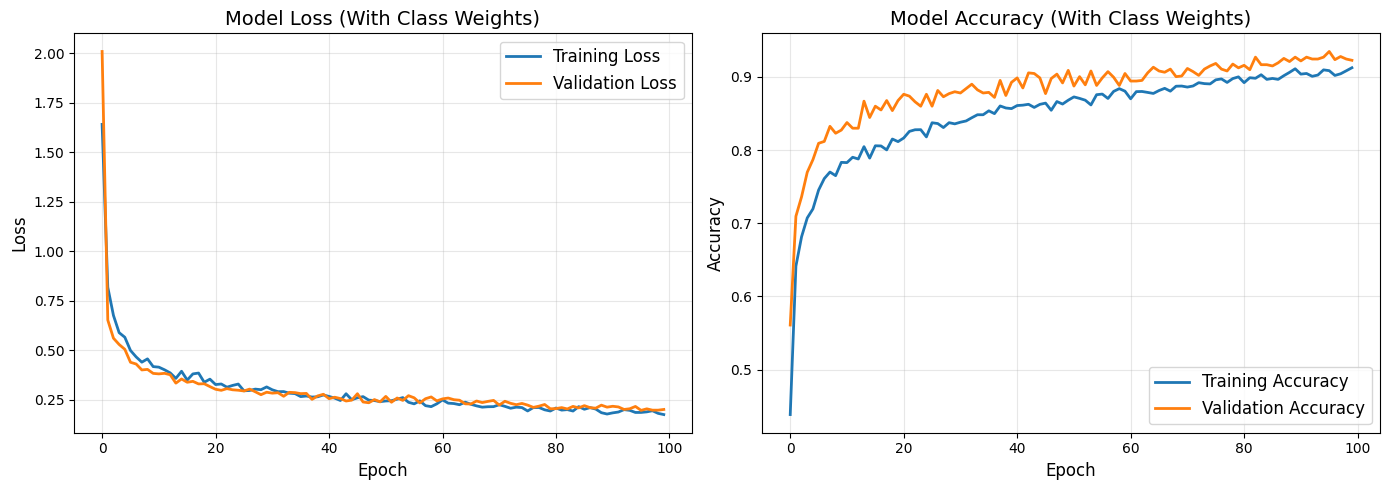


TEST SET EVALUATION
Test Loss:     0.1854
Test Accuracy: 0.9305 (93.05%)

PER-CLASS ACCURACY (With Class Weights)

Class                     Accuracy     Samples    Status    
-----------------------------------------------------------------
កាតាប                      98.21%     56          Good     
កាតាបស្ពាយក្រោយ            93.75%     48          Good     
កុំព្យូទ័រ                 97.01%     67          Good     
កៅអី                      100.00%     34          Good     
ក្ដារខៀន                   97.22%     36          Good     
ខ្មៅដៃ                    100.00%     57          Good     
ជ័រលុប                    100.00%     40          Good     
ដីស                       100.00%     43          Good     
តុ                        100.00%     40          Good     
ទឹកលុប                     98.75%     80          Good     
នាយករង                    100.00%     43          Good     
នាយិកា                    100.00%     63          Good     
បន្ទាត់                   100.00%    

c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6016 (\N{KHMER LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6070 (\N{KHMER VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6031 (\N{KHMER LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6036 (\N{KHMER LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6047 (\N{KHMER LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn

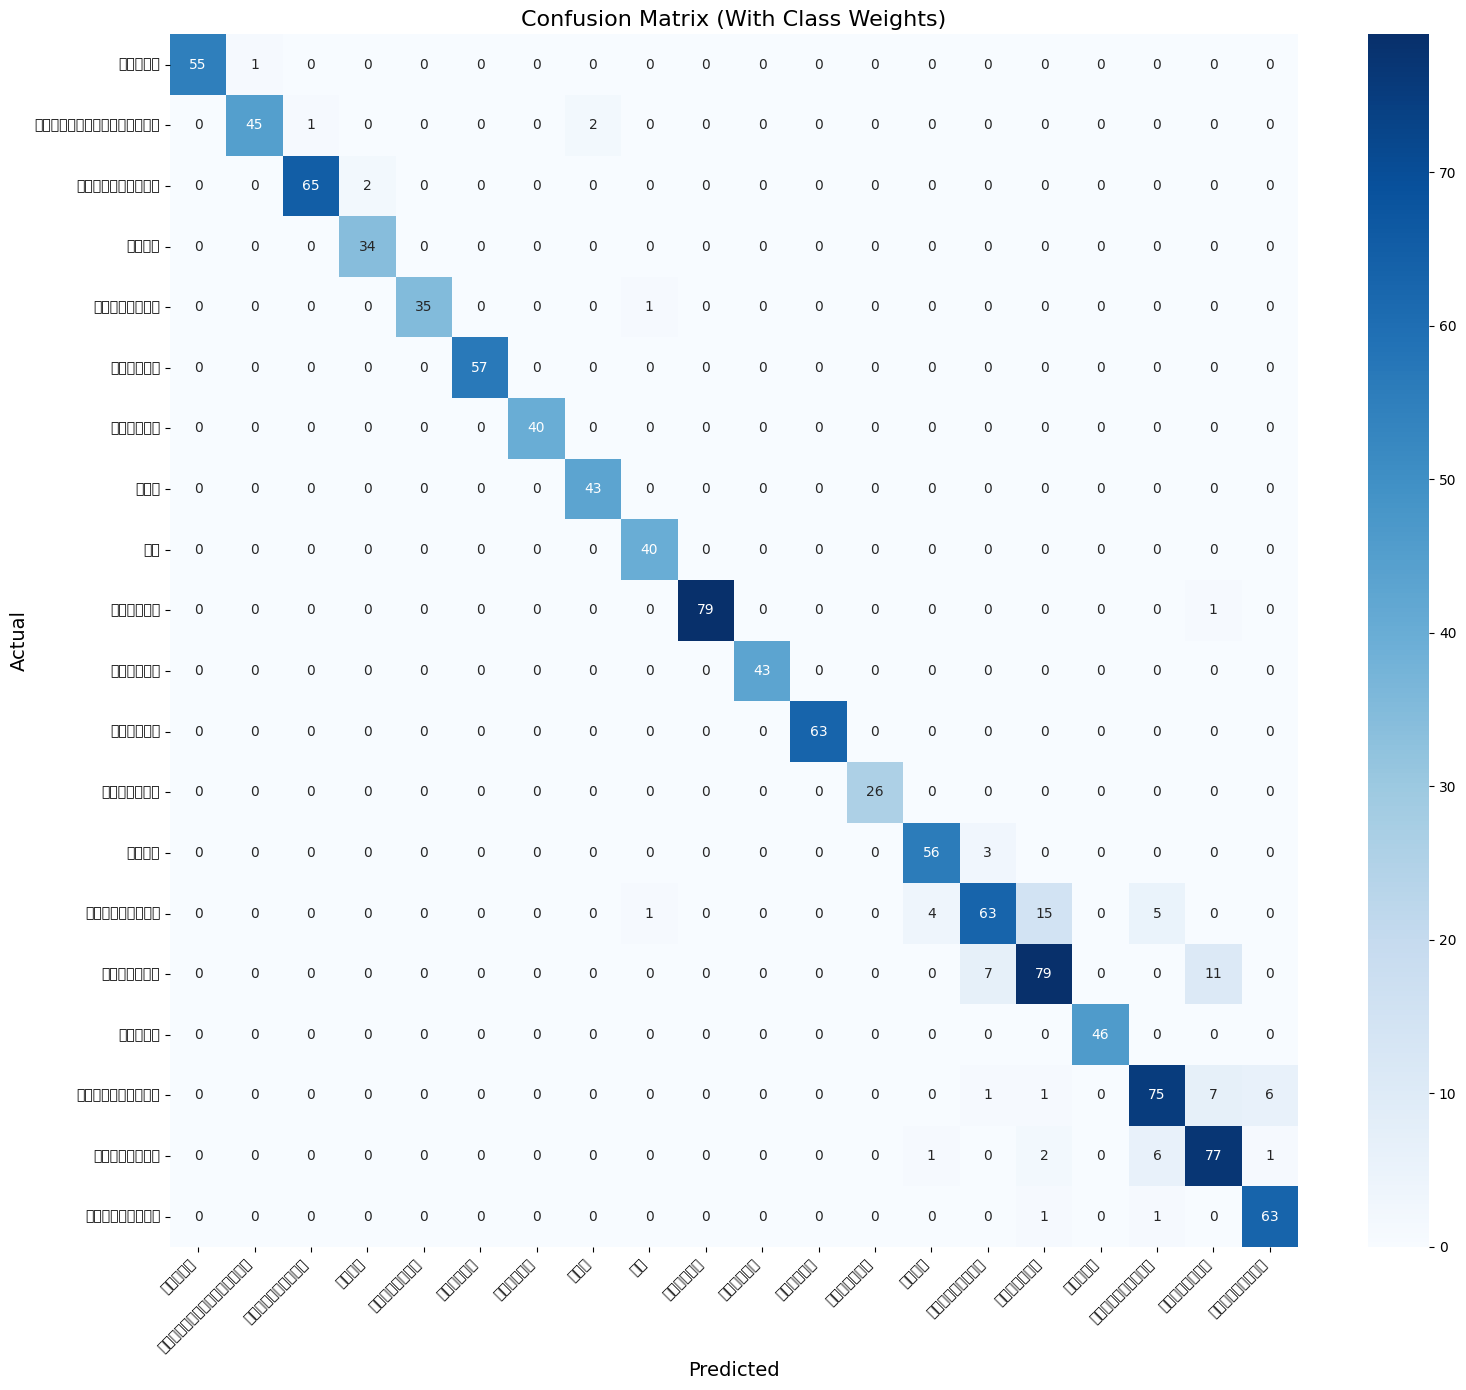


CLASSIFICATION REPORT
                 precision    recall  f1-score   support

          កាតាប       1.00      0.98      0.99        56
កាតាបស្ពាយក្រោយ       0.98      0.94      0.96        48
     កុំព្យូទ័រ       0.98      0.97      0.98        67
           កៅអី       0.94      1.00      0.97        34
       ក្ដារខៀន       1.00      0.97      0.99        36
         ខ្មៅដៃ       1.00      1.00      1.00        57
         ជ័រលុប       1.00      1.00      1.00        40
            ដីស       0.96      1.00      0.98        43
             តុ       0.95      1.00      0.98        40
         ទឹកលុប       1.00      0.99      0.99        80
         នាយករង       1.00      1.00      1.00        43
         នាយិកា       1.00      1.00      1.00        63
        បន្ទាត់       1.00      1.00      1.00        26
           ប៊ិក       0.92      0.95      0.93        59
      ប៊ិកក្រហម       0.85      0.72      0.78        88
        ប៊ិកខៀវ       0.81      0.81      0.81        97
       

In [7]:
# ============================================================
# VISUALIZE TRAINING HISTORY
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(history):
    """
    Plot training and validation loss/accuracy
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('Model Loss (With Class Weights)', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title('Model Accuracy (With Class Weights)', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{Path(MODEL_SAVE_PATH).parent}/training_history.png", dpi=150)
    plt.show()

# Plot training history
plot_training_history(history)

# ============================================================
# EVALUATE ON TEST SET
# ============================================================

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ============================================================
# PER-CLASS ACCURACY (Most important for imbalanced data)
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "=" * 60)
print("PER-CLASS ACCURACY (With Class Weights)")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred_classes)
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print(f"\n{'Class':<25} {'Accuracy':<12} {'Samples':<10} {'Status':<10}")
print("-" * 65)

problematic = []
for i, class_name in enumerate(class_names):
    acc = class_accuracy[i]
    samples = np.sum(y_test == i)
    status = " Good" if acc >= 0.8 else " Okay" if acc >= 0.7 else " Poor"
    print(f"{class_name:<25} {acc*100:>6.2f}%     {samples:<10} {status:<10}")
    if acc < 0.7:
        problematic.append((class_name, acc))

# Show problematic classes
if problematic:
    print("\n" + "=" * 60)
    print(" PROBLEMATIC CLASSES (Below 70% Accuracy)")
    print("=" * 60)
    for class_name, acc in problematic:
        print(f"  - {class_name}: {acc*100:.2f}%")
    print("\n Consider:")
    print("  - Adding more samples for these classes")
    print("  - Trying data augmentation")
    print("  - Adjusting model architecture")
else:
    print("\n" + "=" * 60)
    print(" ALL CLASSES ABOVE 70% ACCURACY!")
    print("   Class weights are working well!")
    print("=" * 60)

# ============================================================
# CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (With Class Weights)', fontsize=16)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{Path(MODEL_SAVE_PATH).parent}/confusion_matrix.png", dpi=150)
plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

## 6 Save model

In [8]:
# ============================================================
# SAVE MODEL AND HISTORY
# ============================================================

import pickle
import json 
# Save the model
model.save(MODEL_SAVE_PATH)
print(f"\n Model saved to: {MODEL_SAVE_PATH}")

# Save class names
# Save as pickle (for Python)
with open(f"{Path(MODEL_SAVE_PATH).parent}/class_names_bgru.pkl", 'wb') as f:
    pickle.dump(class_names, f)
print(f" Class names saved to: class_names_bgru.pkl")

# Save as JSON (more universal, readable)
with open(f"{Path(MODEL_SAVE_PATH).parent}/label_map_bgru.json", 'w', encoding='utf-8') as f:
    json.dump({
        str(i): class_name for i, class_name in enumerate(class_names)
    }, f, ensure_ascii=False, indent=2)
print(f" Label map saved to: label_map_bgru.json")

# Save training history
with open(f"{Path(MODEL_SAVE_PATH).parent}/training_history_bgru.pkl", 'wb') as f:
    pickle.dump(history.history, f)
print(f" Training history saved to: {Path(MODEL_SAVE_PATH).parent}/training_history_bgru.pkl")

print("\n" + "=" * 60)
print(" TRAINING COMPLETE!")
print("=" * 60)


 Model saved to: D:/uni/Intern-1-Project/ksl/models/bgru_best_model_v1.h5
 Class names saved to: class_names_bgru.pkl
 Label map saved to: label_map_bgru.json
 Training history saved to: D:\uni\Intern-1-Project\ksl\models/training_history_bgru.pkl

 TRAINING COMPLETE!
